# Merton Jump-Diffusion

**What this is:** Merton (1976) adds a compound Poisson jump term to geometric Brownian
motion, so the path is continuous most of the time while occasionally being
discontinuous.

**Why it matters:** The compensator $\lambda k$ is subtracted from the drift so that the
jumps do not alter the expected return, which keeps the discounted price a martingale
under the risk neutral measure. The result is a return distribution with heavier tails
and a volatility smile, neither of which pure geometric Brownian motion can produce.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
from __future__ import annotations

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

Array = npt.NDArray[np.float64]
RNG = int | np.random.Generator | None

plt.style.use("seaborn-v0_8")

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | initial asset price |
| $\mu$ | `mu` | drift, the expected rate of return |
| $\sigma$ | `sigma` | volatility of the diffusion component |
| $\lambda$ | `lam` | jump intensity, the expected number of jumps per year |
| $\mu_j$ | `mu_j` | mean of the log jump size |
| $\sigma_j$ | `sigma_j` | standard deviation of the log jump size |
| $k$ | `k` | expected relative jump size, $k = e^{\mu_j + \frac{1}{2}\sigma_j^2} - 1$ |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $Z_{i,j}$ | `Z` | standard normal shocks driving the diffusion |
| $\Delta N_{i,j}$ | `dN` | Poisson jump counts, $\Delta N_{i,j} \sim \text{Poisson}(\lambda \Delta t)$ |
| $Y_{i,j}$ | `Y` | total log jump over the step, $Y_{i,j} \sim \mathcal{N}(\mu_j \Delta N_{i,j},\ \sigma_j^2 \Delta N_{i,j})$ |

In [2]:
SEED = 20260913

S0 = 1
mu = 0.03
sigma = 0.2
lam = 1
mu_j = 0.05
sigma_j = 0.05
T = 1
n = 252
num_paths = 100

## Model

**Continuous time:**

$$dS_t = \left( \mu - \lambda k \right) S_t \, dt + \sigma S_t \, dW_t
+ S_{t^-} \left( e^{Y} - 1 \right) dN_t$$

where $N_t$ is a Poisson process with intensity $\lambda$, the log jump size is
$Y \sim \mathcal{N}(\mu_j, \sigma_j^2)$, and $k = e^{\mu_j + \frac{1}{2}\sigma_j^2} - 1$
is the expected relative jump size. Subtracting the compensator $\lambda k$ from the drift
leaves the expected return unchanged by the jumps.

**Discrete time:** between jumps the process is geometric Brownian motion, so the
diffusion part is sampled exactly in logs rather than by an Euler step,

$$S_{i+1,j} = S_{i,j} \exp\!\left[
\left( \mu - \tfrac{1}{2}\sigma^2 - \lambda k \right) \Delta t
+ \sigma \sqrt{\Delta t} \, Z_{i,j}
+ Y_{i,j} \right]$$

$$Z_{i,j} \sim \mathcal{N}(0,1), \qquad
\Delta N_{i,j} \sim \text{Poisson}(\lambda \Delta t), \qquad
Y_{i,j} \sim \mathcal{N}\!\left( \mu_j \Delta N_{i,j},\ \sigma_j^2 \Delta N_{i,j} \right)$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and $j \in [1, \texttt{num\_paths}]$.

**In code:** `simulate_jump_diffusion`, where the drift, diffusion and jump terms are
built separately and then combined inside the loop. The jump sizes are drawn as
`np.random.normal(loc=mu_j*dN, scale=sigma_j*np.sqrt(dN))`, so a step containing two jumps
is distributed as the sum of two independent single jumps rather than as one jump of
double size. This matches `simulate_bates` in `src/models.py`.

In [3]:
def simulate_jump_diffusion(S0: float, mu: float, sigma: float, lam: float,
                            mu_j: float, sigma_j: float, n: int, num_paths: int,
                            T: float, rng: RNG = None) -> Array:
  """Merton jump-diffusion price paths, shape (n+1, num_paths).

  Between jumps the process is geometric Brownian motion, so the diffusion is
  sampled exactly in logs rather than by an Euler step.
  """
  dt = T/n
  rng = np.random.default_rng(rng)

  S = np.insert(np.zeros((n,num_paths),dtype=float),0,S0,axis=0)
  Z = rng.normal(size=(n,num_paths))
  dN = rng.poisson(lam*dt,size=(n,num_paths))
  # A step containing dN jumps has total log-jump N(dN*mu_j, dN*sigma_j**2),
  # i.e. the sum of dN independent jumps. Scaling a single draw by dN instead
  # would give variance dN**2 * sigma_j**2. Matches src/models.simulate_bates.
  Y = rng.normal(loc=mu_j*dN,scale=sigma_j*np.sqrt(dN),size=(n,num_paths))

  k = np.exp(mu_j+0.5*sigma_j**2)-1

  drift = (mu - 0.5 * sigma ** 2 - lam * k) * dt
  diffusion = lambda i: sigma * np.sqrt(dt) * Z[i]
  jump = lambda i: Y[i]

  for i in range(0,n):
    S[i+1] = S[i] * np.exp(drift + diffusion(i) + jump(i))

  return S

## Results

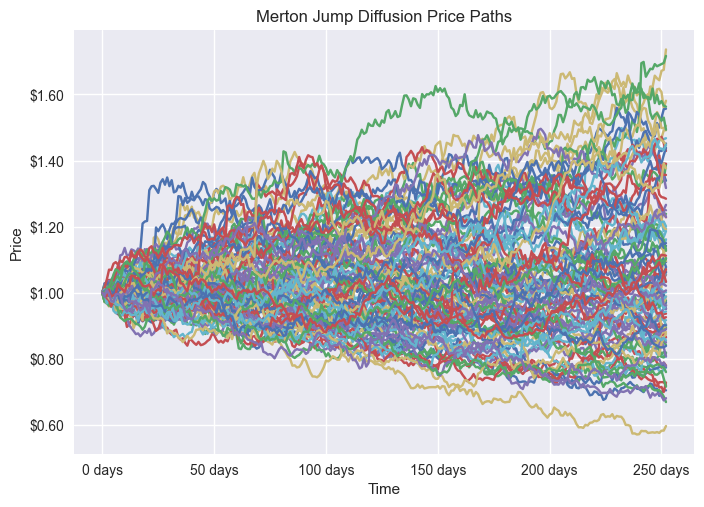

In [4]:
paths = simulate_jump_diffusion(S0,mu,sigma,lam,mu_j,sigma_j,n,num_paths,T,rng=SEED)

plt.plot(paths)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Merton Jump Diffusion Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()